In [83]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

write_output = False

import torch
import rasterio
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt


In [84]:
# 1) Malla 
dx = 250.0
dy = 250.0
dz = 200.0

ncx = 7
ncy = 7
ncz = 20

# Padding 
pad_xy = [2800.0, 1400.0, 1000.0, 700.0, 450.0]

hx = (
    pad_xy[::-1] +          # hacia -X
    [(dx, ncx)] +           # núcleo
    pad_xy                  # hacia +X
)

hy = (
    pad_xy[::-1] +          # hacia -Y
    [(dy, ncy)] +           # núcleo
    pad_xy                  # hacia +Y
)

hz = [
    (dz * 5.0, 5),
    (dz, ncz),
    (dz * 5.0, 5),
]

mesh = TensorMesh([hx, hy, hz], x0=["C", "C", -9000.0])

# Centros de celda
x = mesh.cell_centers[:, 0]
y = mesh.cell_centers[:, 1]
z = mesh.cell_centers[:, 2]

print("shape_cells:", mesh.shape_cells)
print("nC:", mesh.nC)

shape_cells: (17, 17, 30)
nC: 8670


In [85]:
# 2) Topografía

valle_sw = -700.0 * np.exp(
    -((x + 3500.0) / 2800.0) ** 2
    -((y + 3000.0) / 2600.0) ** 2
)

loma_ne = 650.0 * np.exp(
    -((x - 4500.0) / 3200.0) ** 2
    -((y - 3500.0) / 3000.0) ** 2
)

ondulacion_x = 250.0 * np.sin(2 * np.pi * x / 12000.0)
ondulacion_y = 180.0 * np.sin(2 * np.pi * y / 11000.0)

topo_z = valle_sw + loma_ne + ondulacion_x + ondulacion_y



In [137]:
# 3) Modelo MT (conductividad)
sigBG = np.ones(mesh.nC) * 2e-3

# Aire por encima de la topografía
air_cells = z > topo_z
sigBG[air_cells] = 1e-8

sigma = sigBG.copy()

# Anomalía 1: cuerpo conductor 
x1, y1, z1 = -1000.0, 0.0, -3500.0
a1, b1, c1 = 800.0, 1100.0, 500.0

anomaly_left = (
    (x >= x1 - a1) & (x <= x1 + a1) &
    (y >= y1 - b1) & (y <= y1 + b1) &
    (z >= z1 - c1) & (z <= z1 + c1)
)

sigma[anomaly_left] = 10.0


# Anomalía 2: cuerpo resistivo 
x2, y2, z2 = 400.0, 0.0, -1500.0
a2, b2, c2 = -400.0, 800.0, 450.0

anomaly_right = (
    ((x - x2) / a2) ** 2
    + ((y - y2) / b2) ** 2
    + ((z - z2) / c2) ** 2
) <= 1.0

sigma[anomaly_right] = 1e-4

# Aire
sigma[z > topo_z] = 1e-8

sigma[air_cells] = 1e-8

In [138]:
mesh

TensorMesh: 8,670 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     17     -7,225.00      7,225.00    250.00  2,800.00   11.20
   y     17     -7,225.00      7,225.00    250.00  2,800.00   11.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00

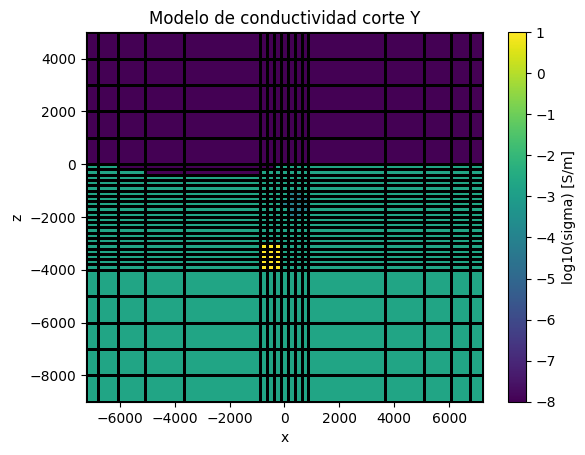

In [139]:
#4) Plot
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="Y")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte Y")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

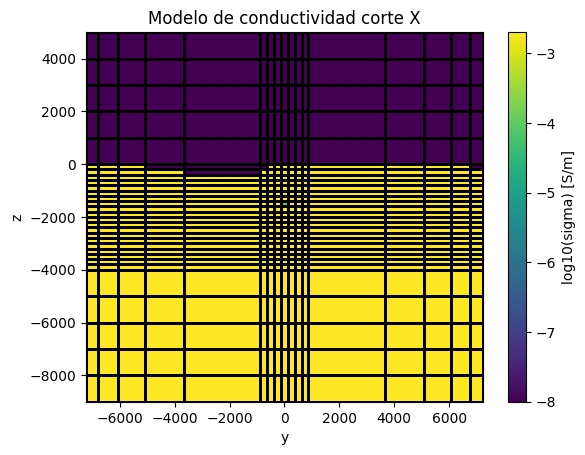

In [140]:
#4) Plot
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="X")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte X")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

In [141]:
# 5) Guardar malla y modelo

mesh.save("mesh_Toy8_MT.json")
np.save("model_Toy8_MT.npy", sigma)